## 03. EDA 

#### NAV Trend Analysis


In [36]:
import pandas as pd
import plotly.express as px

# Loading the cleaned NAV history
nav = pd.read_csv("D:/bluestock_mf_capstone/data/processed/02_nav_history_cleaned.csv")

# Converting the date column
nav["date"] = pd.to_datetime(nav["date"])

# Filtering for 2022–2026
nav = nav[
    (nav["date"] >= "2022-01-01") &
    (nav["date"] <= "2026-12-31")
]

# Plotting NAV trends for all schemes
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends Across 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "NAV": "Net Asset Value",
        "Date": "Date",
        "Scheme_Name": "Scheme"
    }
)

# Highlighting the 2023 Bull Run

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)


# Highlighting the  2024 Correction

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-04-30",
    fillcolor="red",
    opacity=0.12,
    layer="below",
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

# Improving the Layouts
fig.update_layout(
    height=800,
    width=1400,
    hovermode="x unified",
    legend_title="Mutual Fund Scheme",
    template="plotly_white"
)

# Adding a Range Slider
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=[
            dict(count=6, label="6M", step="month", stepmode="backward"),
            dict(count=1, label="1Y", step="year", stepmode="backward"),
            dict(count=3, label="3Y", step="year", stepmode="backward"),
            dict(step="all")
        ]
    )
)

fig.show()

### EDA Finding 1: NAV Growth Across Schemes

**Insight:** Most mutual fund schemes exhibited a sustained upward NAV trend between 2022 and 2025, with accelerated growth during the 2023 bull market period.

**Supporting Chart:** Daily NAV Trends Across 40 Mutual Fund Schemes (2022–2026)


#### AUM Growth Bar Chart

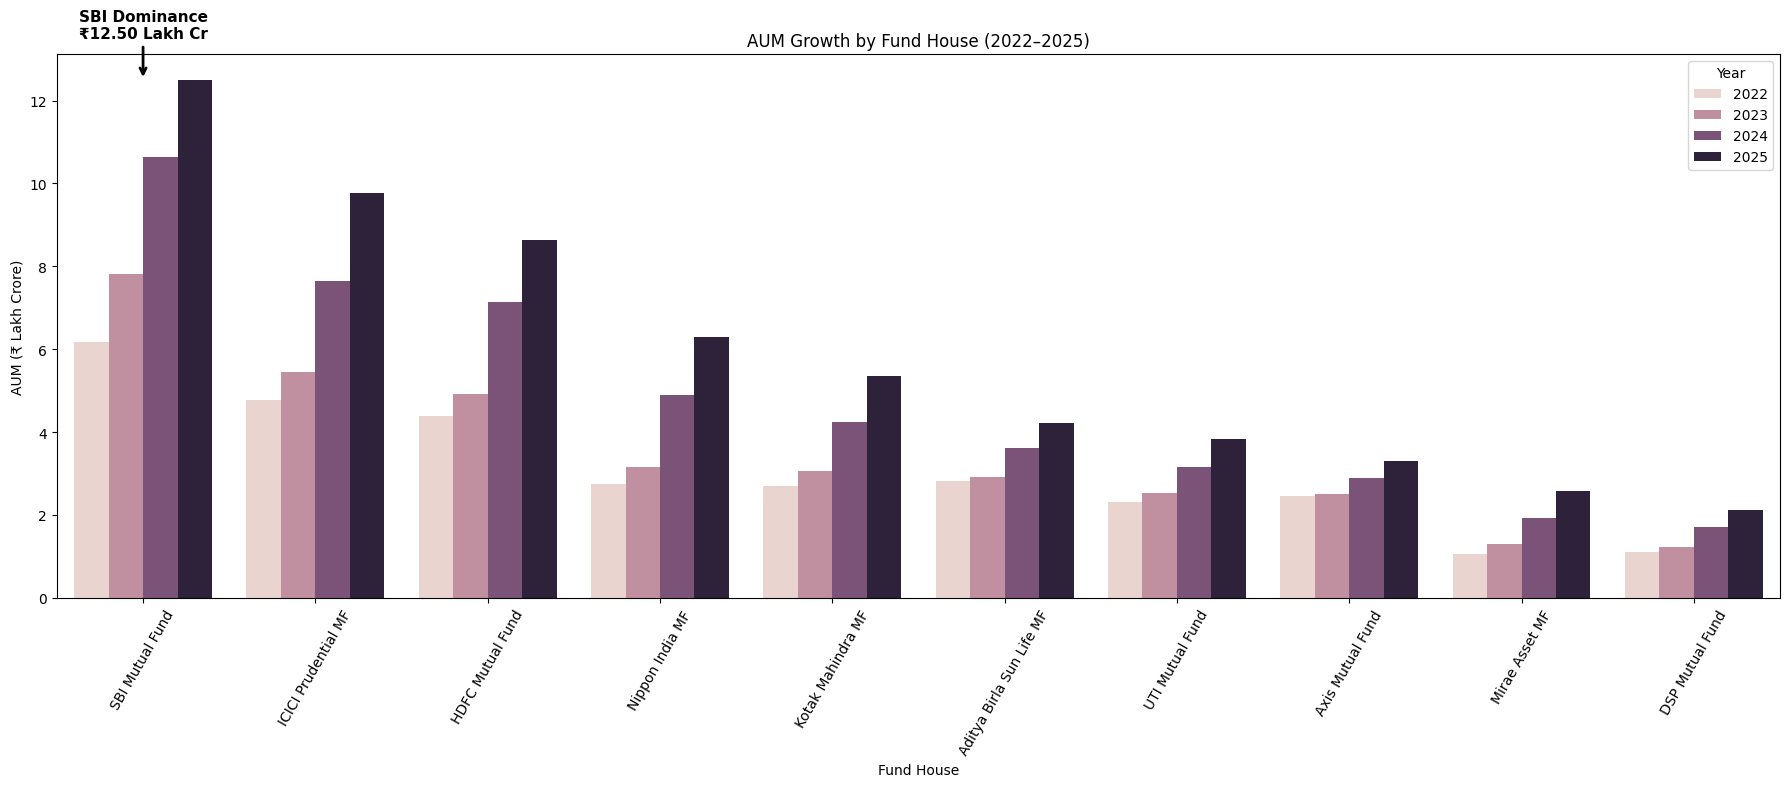

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:/bluestock_mf_capstone/data/processed/03_aum_by_fund_house_cleaned.csv")

# Converting the  date column
df["date"] = pd.to_datetime(df["date"])

# Extracting the fund year
df["year"] = df["date"].dt.year

# Keeping  only the years from 2022 to 2025
df = df[df["year"].between(2022, 2025)]

# Aggregating the  yearly AUM
yearly_aum = (
    df.groupby(["year", "fund_house"], as_index=False)
      .agg({
          "aum_lakh_crore": "mean"  
      })
)
# Sorting the fund houses by 2025 AUM

order = (
    yearly_aum[yearly_aum["year"] == 2025]
    .sort_values("aum_lakh_crore", ascending=False)
    ["fund_house"]
)

plt.figure(figsize=(18, 8))

ax = sns.barplot(
    data=yearly_aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year",
    order=order
)


sbi_2025 = yearly_aum[
    (yearly_aum["fund_house"].str.contains("SBI Mutual Fund", case=False)) &
    (yearly_aum["year"] == 2025)
]

if not sbi_2025.empty:
    value = sbi_2025["aum_lakh_crore"].iloc[0]

    plt.annotate(
        f"SBI Dominance\n₹{value:.2f} Lakh Cr",
        xy=(0, value),          
        xytext=(0, value + 1),
        ha="center",
        fontsize=11,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", lw=2)
    )


plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")
plt.xticks(rotation=60)
plt.legend(title="Year")

plt.tight_layout()
plt.show()


## EDA Finding 2: Fund House AUM Dominance

**Insight:** SBI Mutual Fund maintained the largest asset base among all fund houses, reaching approximately ₹12.5 lakh crore AUM by 2025.

**Supporting Chart:** AUM Growth by Fund House (2022-2025)




####    SIP Inflow time-series


In [12]:
import pandas as pd
import plotly.graph_objects as go

# Load data
sip = pd.read_csv("D:/bluestock_mf_capstone/data/processed/04_monthly_sip_inflows_processed.csv")

# Converting the  month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Filtering from  Jan 2022 to  Dec 2025
sip = sip[
    (sip["month"] >= "2022-01-01") &
    (sip["month"] <= "2025-12-31")
]

# Finding the peak SIP inflow
peak_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

# Creating the chart for SIP inflow
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=sip["month"],
        y=sip["sip_inflow_crore"],
        mode="lines+markers",
        name="SIP Inflow",
        hovertemplate="<b>%{x|%b %Y}</b><br>₹ %{y:,.0f} Cr<extra></extra>"
    )
)

# Highlighting the all-time high Monthly SIP inflow
fig.add_trace(
    go.Scatter(
        x=[peak_row["month"]],
        y=[peak_row["sip_inflow_crore"]],
        mode="markers+text",
        text=[f"₹{peak_row['sip_inflow_crore']:,.0f} Cr"],
        textposition="top center",
        marker=dict(size=14),
        name="All-Time High"
    )
)

# Adding Annotation
fig.add_annotation(
    x=peak_row["month"],
    y=peak_row["sip_inflow_crore"],
    text=(
        f"<b>All-Time High</b><br>"
        f"₹{peak_row['sip_inflow_crore']:,.0f} Cr"
    ),
    showarrow=True,
    arrowhead=2,
    ax=60,
    ay=-60
)

fig.update_layout(
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    hovermode="x unified",
    template="plotly_white",
    height=650
)

fig.update_xaxes(
    rangeslider_visible=True
)

fig.show()

### EDA Finding 3: SIP Participation Growth

Insight: Monthly SIP inflows increased consistently throughout the study period and reached an all-time high of ₹31,002 crore in December 2025.

Supporting Chart: Monthly SIP Inflow

#### Category Inflow Heatmap

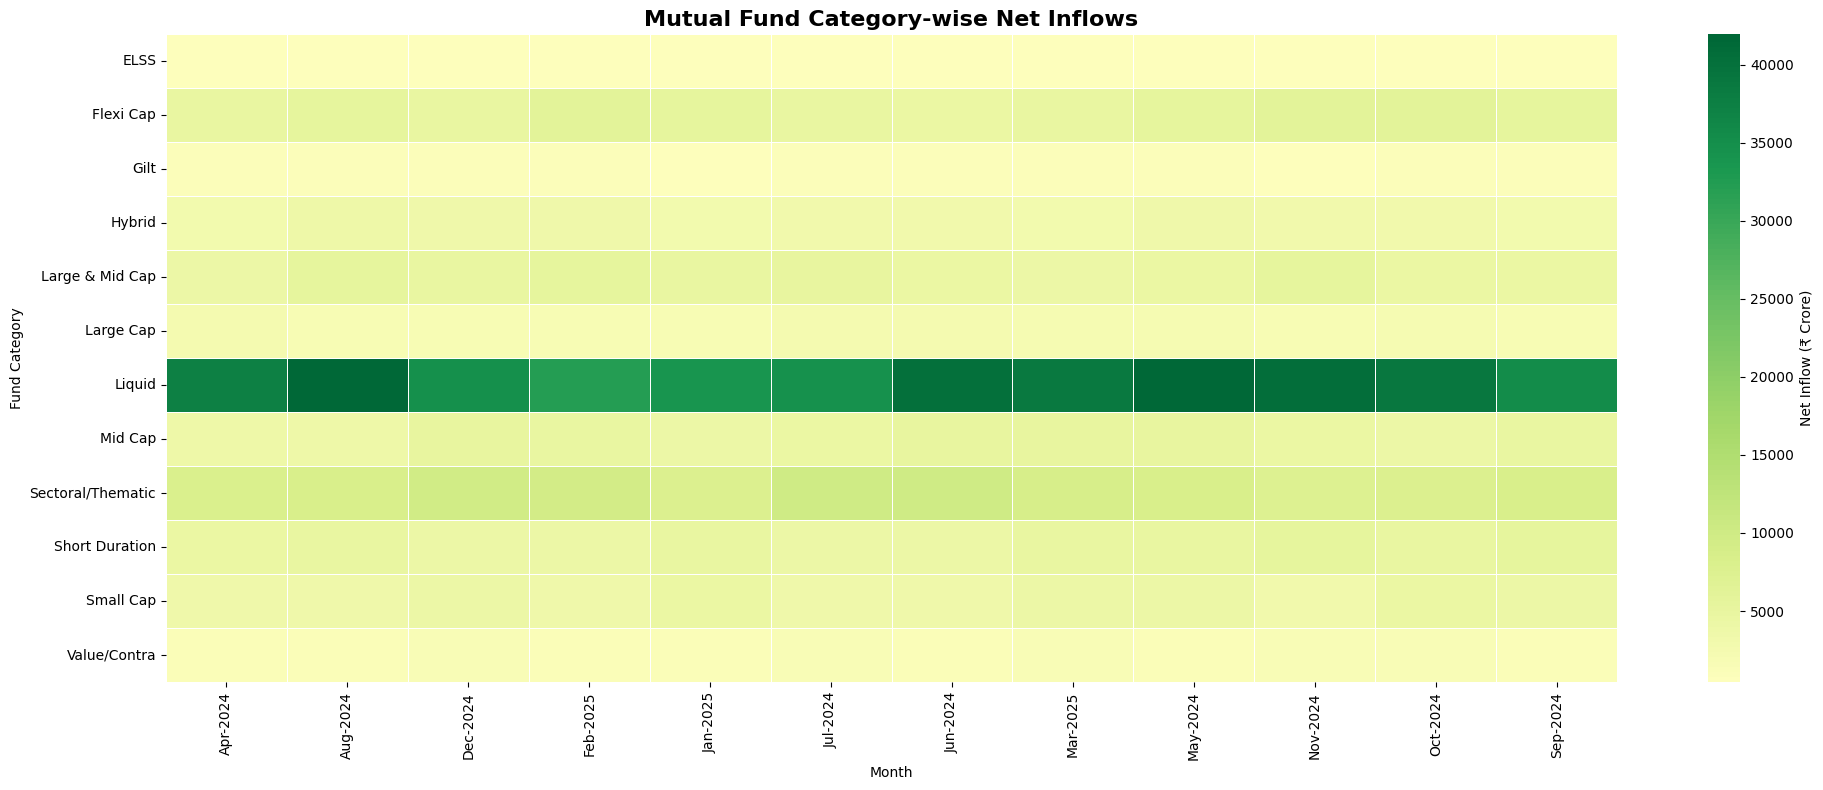

In [35]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Loading the dataset
df = pd.read_csv("D:/bluestock_mf_capstone/data/processed/05_category_inflows_processed.csv")

df["month"]=pd.to_datetime(df['month'])

# Creating month labels
df["month_label"] = df["month"].dt.strftime("%b-%Y")

heatmap_data = df.pivot_table(
    index="category",
    columns="month_label",
    values="net_inflow_crore",
    aggfunc="sum"
)

## Plotting the heatmap

plt.figure(figsize=(20,8))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",      # Red = low/outflow, Green = high inflow
    center=0,
    linewidths=0.5,
    cbar_kws={
        "label": "Net Inflow (₹ Crore)"
    }
)

plt.title(
    "Mutual Fund Category-wise Net Inflows",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### EDA Finding 4: Category-Level Investor Preferences

Insight: Equity-oriented categories attracted the strongest and most consistent inflows, while debt categories experienced comparatively volatile investor behavior.

Supporting Chart:Mutual Fund Category-wise Net Inflows

#### Investor Demographics

In [1]:
import pandas as pd
df=pd.read_csv("D:/bluestock_mf_capstone/data/processed/08_investor_transactions_cleaned.csv")
print(df.columns.tolist())
print(df.head())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female      

#####  1 Age Group Distribution

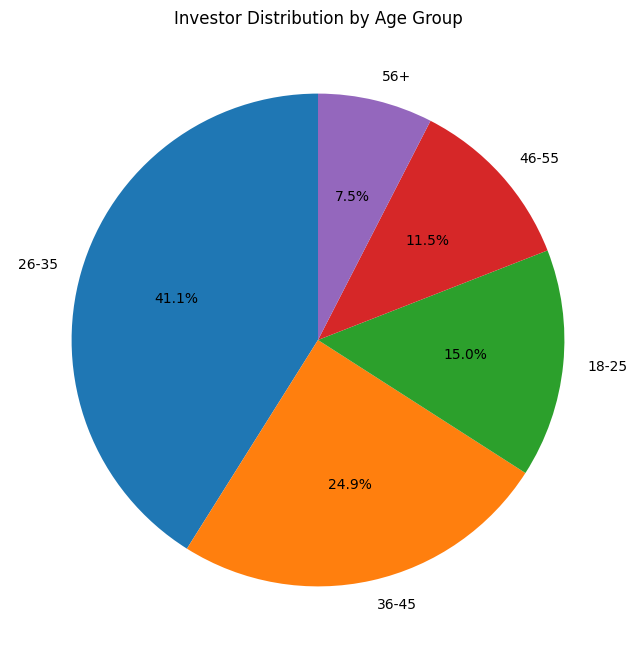

In [2]:
import matplotlib.pyplot as plt

#df["age_group"].value_counts().plot.pie(autopct="%1.1f%%")
age_dist = df["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.show()

##### 2. SIP amount box plot

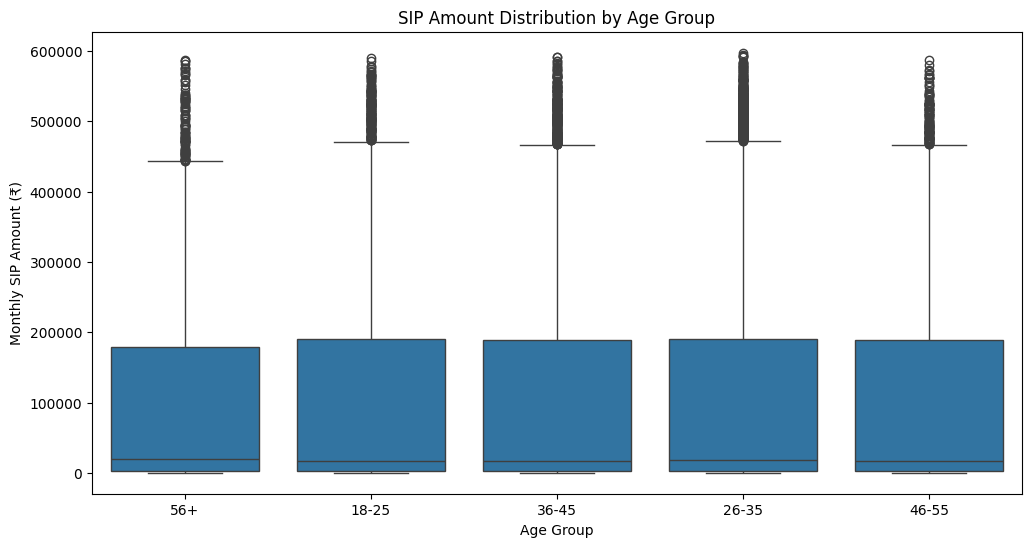

In [ ]:
# Plotting the boxplot for the SIP amount 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xlabel("Age Group")
plt.ylabel("Monthly SIP Amount (₹)")

plt.show()

##### 3. Gender Split pie chart

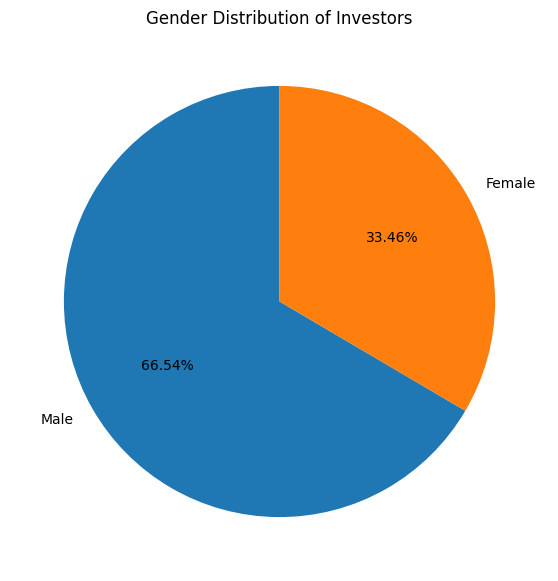

In [ ]:
# Plotting the gender distribution
gender_dist = df["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_dist,
    labels=gender_dist.index,
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.show()

### DA Finding 6: Gender Participation

Insight: Male investors represented the larger share of mutual fund participants, although female investor participation contributed significantly to overall investment activity.

Supporting Chart: Gender Distribution of Investors

### Geographic Distribution

In [14]:
# Reading the data
import pandas as pd
df=pd.read_csv("D:/bluestock_mf_capstone/data/processed/08_investor_transactions_cleaned.csv")

# Filtering the SIP transactions
sip_df = df[
    df["transaction_type"]
    .str.upper()
    .str.contains("SIP")
]

# Aggregating  the SIP amount by state
state_sip=sip_df.groupby("state")['amount_inr'].sum().reset_index().sort_values("amount_inr",ascending=False)

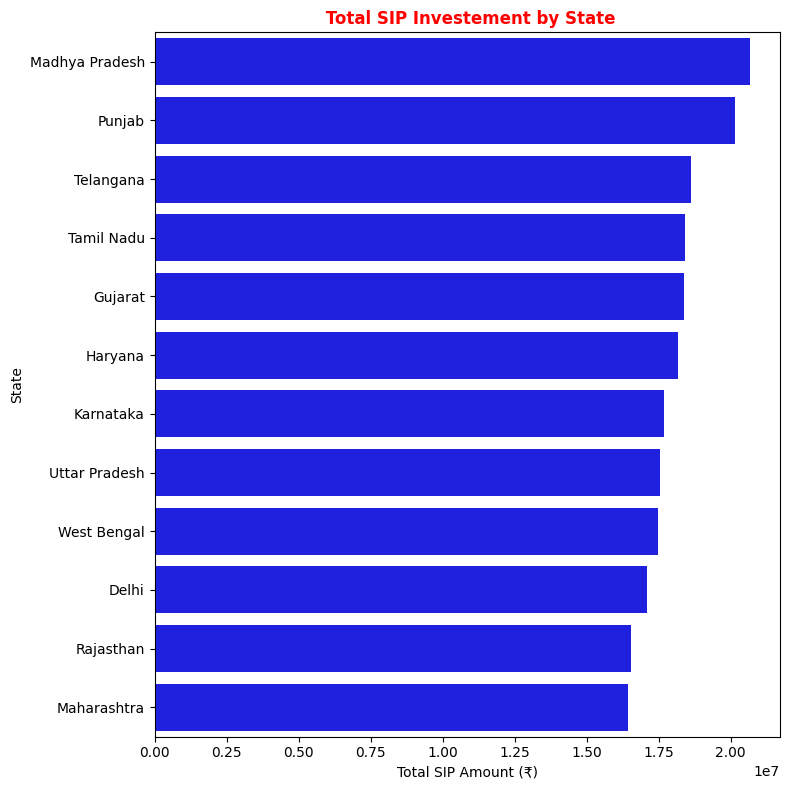

In [26]:
#Plotting the horizontal bar chart

from turtle import color

from pandas import col
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state",
    color="blue"
)

plt.title(" Total SIP Investement by State",
          fontsize=12,
          fontweight="bold",
          color="red")

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### EDA Finding 7: Geographic Concentration of Investments

Insight: A small number of states accounted for a disproportionately large share of total SIP investments, indicating geographic concentration of mutual fund adoption.

Supporting Chart: SIP Amount by State (Horizontal Bar Chart)

In [27]:
print(df["city_tier"].value_counts())

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


In [29]:
## Aggregating the SIP amount by city 
segment_data = (
    sip_df.groupby("city_tier")
    ["amount_inr"]
    .sum()
)

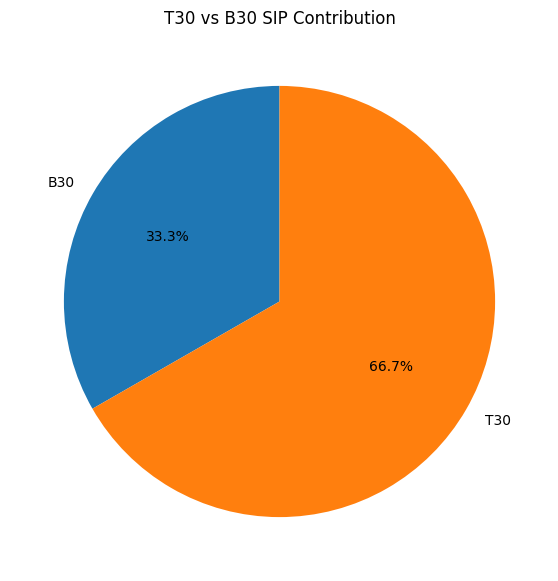

In [30]:
## Plotting the pie chart 
plt.figure(figsize=(7,7))

plt.pie(
    segment_data,
    labels=segment_data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 SIP Contribution"
)

plt.show()

### EDA Finding 8: Expansion Beyond Major Cities

Insight: B30 cities contributed a meaningful share of SIP investments, demonstrating increasing mutual fund penetration beyond traditional metropolitan markets.

Supporting Chart: T30 vs B30 Contribution Donut Chart

### Folio count growth

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Loading the cleaned data
folio = pd.read_csv("D:/bluestock_mf_capstone/data/processed/folio_growth_cleaned.csv")

folio["month"] = pd.to_datetime(folio["month"])

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=folio["month"],
        y=folio["total_folios_crore"],
        mode="lines+markers",
        name="Folio Count"
    )
)

# Key milestones
milestones = [15, 20, 25]

for milestone in milestones:
    closest = folio.iloc[
        (folio["total_folios_crore"] - milestone).abs().argsort()[:1]
    ]

    fig.add_annotation(
        x=closest["month"].iloc[0],
        y=closest["total_folios_crore"].iloc[0],
        text=f"{milestone} Cr",
        showarrow=True
    )

# Starting point
fig.add_annotation(
    x=folio["month"].min(),
    y=13.26,
    text="Jan 2022<br>13.26 Cr",
    showarrow=True
)

# End point
fig.add_annotation(
    x=folio["month"].max(),
    y=26.12,
    text="Dec 2025<br>26.12 Cr",
    showarrow=True
)

fig.update_layout(
    title="Mutual Fund Folio Growth (Jan 2022 – Dec 2025)",
    xaxis_title="Month",
    yaxis_title="Folios (Crore)",
    hovermode="x unified",
    template="plotly_white",
    height=650
)

fig.update_xaxes(rangeslider_visible=True)

fig.show()

### EDA Finding 9: Folio Base Expansion

Insight: Total mutual fund folios nearly doubled from 13.26 crore in January 2022 to 26.12 crore in December 2025, reflecting strong retail investor onboarding.

Supporting Chart: Mutual Fund Folio Growth Trend Chart

### NAV return correlation matrix

In [39]:
import pandas as pd
sch=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\07_scheme_performance_cleaned.csv")
print(sch["scheme_name"].unique())

<StringArray>
[            'SBI Bluechip Fund - Regular Plan - Growth',
              'SBI Bluechip Fund - Direct Plan - Growth',
            'SBI Small Cap Fund - Regular Plan - Growth',
             'SBI Small Cap Fund - Direct Plan - Growth',
          'SBI Magnum Gilt Fund - Regular Plan - Growth',
             'HDFC Top 100 Fund - Regular Plan - Growth',
              'HDFC Top 100 Fund - Direct Plan - Growth',
    'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
     'HDFC Mid-Cap Opportunities Fund - Direct - Growth',
          'HDFC Short Term Debt Fund - Regular - Growth',
            'ICICI Pru Bluechip Fund - Regular - Growth',
             'ICICI Pru Bluechip Fund - Direct - Growth',
              'ICICI Pru Midcap Fund - Regular - Growth',
     'ICICI Pru Value Discovery Fund - Regular - Growth',
              'ICICI Pru Liquid Fund - Regular - Growth',
        'Nippon India Large Cap Fund - Regular - Growth',
         'Nippon India Large Cap Fund - Direct - Growth',


In [ ]:
#Loading both files
import pandas as pd

nav = pd.read_csv(
    r"D:\bluestock_mf_capstone\data\processed\02_nav_history_cleaned.csv"
)

scheme = pd.read_csv(
    r"D:\bluestock_mf_capstone\data\processed\07_scheme_performance_cleaned.csv"
)

In [49]:
#Merging  schemes names

nav = nav.merge(
    scheme[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [50]:
# selecting top 10 funds
top10 = (
    scheme.sort_values(
        "aum_crore",
        ascending=False
    )
    .head(10)
)

selected_codes = top10["amfi_code"]

#filtering 
nav = nav[
    nav["amfi_code"].isin(selected_codes)
]


In [51]:
##Creating NAV Matrix
nav["date"] = pd.to_datetime(nav["date"])

nav_matrix = nav.pivot_table(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Computing daily returns
returns = nav_matrix.pct_change()

returns = returns.dropna()

# Correlation Matrix
corr_matrix = returns.corr()


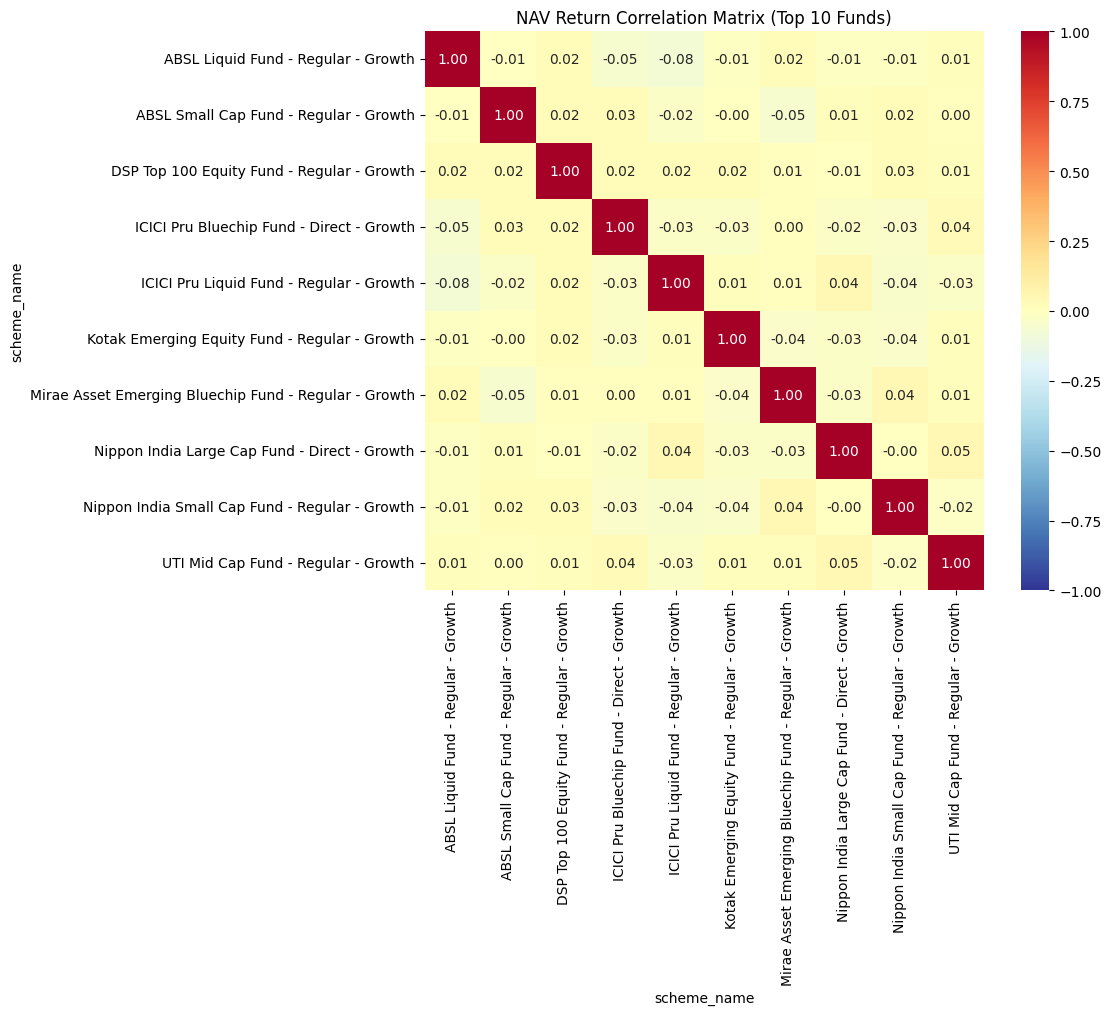

In [52]:
## Plotting the heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title(
    "NAV Return Correlation Matrix (Top 10 Funds)"
)

plt.tight_layout()
plt.show()

### Sector Allocation Donut 

In [1]:
#Loading and cleaning the file 
import pandas as pd

holdings = pd.read_csv(
    r"D:\bluestock_mf_capstone\data\processed\09_portfolio_cleaned.csv"
)

holdings["weight_pct"] = pd.to_numeric(
    holdings["weight_pct"],
    errors="coerce"
)

holdings = holdings.dropna(
    subset=["sector", "weight_pct"]
)

In [7]:
print("Rows:", len(holdings))
print("Funds:", holdings["amfi_code"].nunique())
print("Sectors:", holdings["sector"].nunique())

sector_alloc = (
    holdings.groupby("sector")["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
)

print(sector_alloc)

Rows: 322
Funds: 34
Sectors: 14
sector
Banking           62840.29
IT                38477.11
Pharma            34606.10
Automobile        34296.97
Utilities         25108.63
Infrastructure    22433.39
FMCG              21151.15
Telecom           16051.45
Energy            15286.54
Diversified       13897.79
Cement            11611.97
Paints            10612.07
Consumer Goods     9859.70
NBFC               8615.46
Name: market_value_cr, dtype: float64


In [4]:
print("Equity funds found:", holdings)
print(holdings.head())

Equity funds found:      amfi_code stock_symbol                 stock_name       sector  \
0       119551    POWERGRID     Power Grid Corporation    Utilities   
1       119551     HDFCBANK              HDFC Bank Ltd      Banking   
2       119551       GRASIM      Grasim Industries Ltd  Diversified   
3       119551      DRREDDY   Dr. Reddy's Laboratories       Pharma   
4       119551   ASIANPAINT           Asian Paints Ltd       Paints   
..         ...          ...                        ...          ...   
317     149324     DIVISLAB        Divi's Laboratories       Pharma   
318     149324   BHARTIARTL          Bharti Airtel Ltd      Telecom   
319     149324          TCS  Tata Consultancy Services           IT   
320     149324   INDUSINDBK          IndusInd Bank Ltd      Banking   
321     149324         NTPC                   NTPC Ltd    Utilities   

     weight_pct  market_value_cr  current_price_inr portfolio_date  
0         13.85           737.09            6011.08     20

In [8]:
scheme = pd.read_csv(
    r"D:\bluestock_mf_capstone\data\processed\07_scheme_performance_cleaned.csv")

equity_funds = scheme[
    scheme["category"].str.contains(
        "Equity",
        case=False,
        na=False
    )
]["amfi_code"]

holdings["amfi_code"] = holdings["amfi_code"].astype(str)
scheme["amfi_code"] = scheme["amfi_code"].astype(str)


In [9]:
print(
    holdings["amfi_code"].dtype,
    scheme["amfi_code"].dtype
)

str str


In [10]:
# Aggregating Sector Weights
sector_alloc = (
    holdings.groupby("sector")["weight_pct"]
    .mean()
    .reset_index()
)

# sorting
sector_alloc = sector_alloc.sort_values(
    "weight_pct",
    ascending=False
)

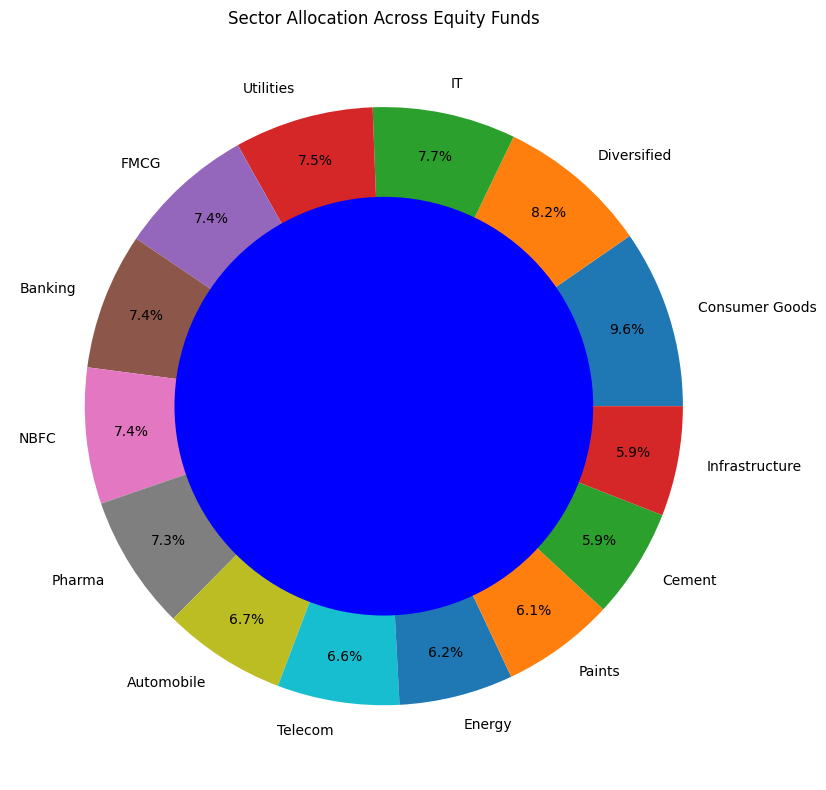

In [11]:
## Creating Donut Chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.pie(
    sector_alloc["weight_pct"],
    labels=sector_alloc["sector"],
    autopct="%1.1f%%",
    pctdistance=0.85
)

# Donut hole
centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="blue"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(
    "Sector Allocation Across Equity Funds"
)

plt.tight_layout()

plt.show()

### EDA Finding 10: Portfolio Sector Concentration

Insight: Equity mutual fund portfolios showed significant concentration in a few sectors such as Financial Services, Information Technology, and Healthcare, highlighting common investment themes across fund managers.

Supporting Chart: Sector Allocation Across Equity Funds Donut Chart